# Retail Sales & Customer Analytics using Python and NumPy

**A beginner-to-intermediate Data Analyst portfolio project.**

This notebook walks through a complete, real-world style Data Analyst
workflow: taking a raw retail sales CSV file and turning it into
business KPIs, visual charts, and written business insights - using
Python and NumPy as the main analysis tools.

By the end of this notebook you will be able to:
- Load and clean a messy real-world-style dataset
- Convert tabular data into NumPy arrays for analysis
- Calculate business KPIs using NumPy functions
- Filter data using Boolean masking and `np.where()`
- Group and aggregate data the way SQL's `GROUP BY` does, but in NumPy
- Build clear, labeled visualizations with Matplotlib
- Turn numbers into business insights and recommendations


## 2. Business Problem

**Scenario:** A retail company sells products online across multiple
Indian cities. Management has transaction-level sales data but no easy
way to answer basic business questions. They have asked for an analysis
that identifies top-performing products, categories, cities, and
customers, and explains monthly sales trends and profitability.

**Why this matters:** Without analysis, a business is making decisions
blind - guessing which products to restock, which regions need
attention, and which customers are most valuable. Data Analysts turn
raw transaction logs into decisions management can act on.

We will answer more than 20 specific business questions in the
sections below (see the project README for the full list, grouped into
Basic, Product, Customer, Geographic, and Time analysis).


## 3. Import Libraries

- **NumPy**: our main analysis tool - fast numeric arrays and
  vectorized calculations.
- **pandas**: used only to conveniently *read* the CSV (a file that mixes
  text and numeric columns is painful to load with raw NumPy). Once
  loaded, we convert the columns we analyze into NumPy arrays.
- **Matplotlib**: for charts.

We import our own reusable project code from `src/` so this notebook
stays focused on *explaining* the analysis rather than repeating code
that also lives in the Streamlit app.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_raw_data, clean_data, to_numpy_arrays
from analysis import *
from visualization import *

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.4.4
Pandas version: 3.0.2


## 4. Load Dataset

**What are we doing?** Reading `data/retail_sales.csv` into memory.

**Why NumPy-aware loading?** Pure NumPy functions like `np.loadtxt()`
and `np.genfromtxt()` expect data that is mostly numeric. Our dataset
mixes text columns (Customer_Name, City, Category) with numeric columns
(Quantity, Unit_Price, Sales) and even has some intentionally messy
values (blank cells, bad dates). Loading that reliably needs pandas'
`read_csv()`. Immediately after this, in Section 7, we convert the
numeric columns into NumPy arrays - because NumPy is our analysis tool
from that point on.

**What would happen if we skipped this step?** We could not do any
analysis at all - there would be no data in memory.


In [2]:
raw_df = load_raw_data("../data/retail_sales.csv")
print("Shape (rows, columns):", raw_df.shape)
raw_df.head()

Shape (rows, columns): (2015, 17)


,Order_ID,Order_Date,Customer_ID,Customer_Name,City,State,Region,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode,Customer_Type
0,ORD00165,2024-01-18,CUST0528,Vivaan Kumar,Ahmedabad,Gujarat,West,Clothing,Denim Jeans,7.0,529.60,0.00,3707.20,2199.98,1507.22,Credit Card,New
1,ORD00663,2024-08-29,CUST0485,Saanvi Iyer,Noida,Uttar Pradesh,North,Clothing,Women Kurti,2.0,1879.23,0.00,3758.46,2222.02,1536.44,UPI,Returning
2,ORD01492,2024-07-02,CUST0106,Vihaan Mehta,Chennai,Tamil Nadu,South,Books,Cook Book,2.0,634.31,0.05,1205.19,939.85,265.34,Credit Card,New
3,ORD01178,2024-06-30,CUST0175,Pooja Yadav,Kolkata,West Bengal,East,grocery,Basmati Rice 5kg,8.0,282.73,0.00,2261.84,1438.21,823.63,Credit Card,Returning
4,ORD01267,2023-10-27,CUST0226,Arjun Kumar,Mumbai,Maharashtra,West,ELECTRONICS,Wireless Mouse,2.0,2496.93,0.05,4744.17,2664.86,2079.31,UPI,Returning


## 5. Understand the Dataset

Before cleaning or analyzing anything, a Data Analyst must understand
what each column means and what condition the data is in.

**Columns:**
| Column | Meaning |
|---|---|
| Order_ID | Unique identifier for each transaction |
| Order_Date | Date the order was placed |
| Customer_ID / Customer_Name | Who placed the order |
| City / State / Region | Where the order was placed |
| Category / Product | What was purchased |
| Quantity | Units purchased |
| Unit_Price | Price per unit (before discount) |
| Discount | Discount applied, as a decimal (0.10 = 10%) |
| Sales | Revenue from the order after discount |
| Cost | Cost to the business for that order |
| Profit | Sales minus Cost |
| Payment_Mode | How the customer paid |
| Customer_Type | New or Returning customer |


In [3]:
print(raw_df.info())
print("\nMissing values per column:")
print(raw_df.isna().sum())
print("\nRow count:", len(raw_df))
print("Unique Order_IDs:", raw_df["Order_ID"].nunique(), "(duplicates exist if this is less than row count)")

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       2015 non-null   str    
 1   Order_Date     1993 non-null   str    
 2   Customer_ID    2015 non-null   str    
 3   Customer_Name  2015 non-null   str    
 4   City           2015 non-null   str    
 5   State          2015 non-null   str    
 6   Region         2015 non-null   str    
 7   Category       2015 non-null   str    
 8   Product        2015 non-null   str    
 9   Quantity       1981 non-null   float64
 10  Unit_Price     1982 non-null   float64
 11  Discount       2015 non-null   float64
 12  Sales          1916 non-null   float64
 13  Cost           1916 non-null   float64
 14  Profit         1916 non-null   float64
 15  Payment_Mode   2015 non-null   str    
 16  Customer_Type  2015 non-null   str    
dtypes: float64(6), str(11)
memory usage: 457.7 KB
None

Missing val

## 6. Data Cleaning

**Issues found in this dataset (by design, for practice):**
- Missing Quantity / Unit_Price / Order_Date in some rows
- Negative Quantity values (impossible in real sales)
- Duplicate Order_IDs
- Inconsistent Category text (`"electronics"`, `"ELECTRONICS"`, `" Electronics"`)
- Extra whitespace in text fields
- A few invalid dates

**Why cleaning is necessary:** A single negative Quantity or duplicate
order can silently distort every KPI built on top of it (totals,
averages, top products). Cleaning first means every number we calculate
later is trustworthy.

**How we fix it:** see `src/data_loader.py -> clean_data()`. The
cleaning logic lives in one shared file so the notebook and the
Streamlit dashboard always agree on the same clean dataset.

**How we verify it:** we compare row counts and re-check for
missing/duplicate/negative values after cleaning.


In [4]:
clean_df = clean_data(raw_df)

print(f"Rows before cleaning: {len(raw_df)}")
print(f"Rows after cleaning:  {len(clean_df)}")
print(f"Rows removed:         {len(raw_df) - len(clean_df)}")

# Verification
print("\nRemaining missing values:", clean_df[["Quantity","Unit_Price","Order_Date"]].isna().sum().sum())
print("Remaining negative quantities:", (clean_df["Quantity"] <= 0).sum())
print("Remaining duplicate Order_IDs:", clean_df["Order_ID"].duplicated().sum())
print("Unique category values now:", sorted(clean_df["Category"].unique()))

Rows before cleaning: 2015
Rows after cleaning:  1860
Rows removed:         155

Remaining missing values: 0
Remaining negative quantities: 0
Remaining duplicate Order_IDs: 0
Unique category values now: ['Beauty', 'Books', 'Clothing', 'Cloths', 'Electronics', 'Grocery', 'Home & Kitchen', 'Sports']


## 7. NumPy Array Conversion

**Python list vs NumPy array - why does it matter?**

A Python `list` can hold anything and does math element-by-element only
if you write a loop. A NumPy `array` is built for numbers: operations
like `array * 2` apply to every element at once (this is called
**vectorization**), and NumPy's C-based internals make this much faster
than a Python loop on large data.


In [5]:
python_list = [10, 20, 30, 40]
numpy_array = np.array(python_list)

# Doubling every value:
doubled_list = [x * 2 for x in python_list]   # needs a loop / comprehension
doubled_array = numpy_array * 2                # broadcasting - no loop needed

print("Python list doubled:", doubled_list)
print("NumPy array doubled:", doubled_array)
print("Array type:", type(numpy_array), "dtype:", numpy_array.dtype)

Python list doubled: [20, 40, 60, 80]
NumPy array doubled: [20 40 60 80]
Array type: <class 'numpy.ndarray'> dtype: int64


Now we convert the cleaned DataFrame's numeric and category columns
into NumPy arrays. From this point on, our analysis uses these arrays
directly.


In [6]:
arrays = to_numpy_arrays(clean_df)

print("Available arrays:", list(arrays.keys()))
print("\nsales array (first 10):", arrays["sales"][:10])
print("sales array shape:", arrays["sales"].shape, " dtype:", arrays["sales"].dtype)

Available arrays: ['quantity', 'unit_price', 'discount', 'sales', 'cost', 'profit', 'category', 'city', 'region', 'customer_id', 'payment_mode', 'customer_type', 'order_date', 'month']

sales array (first 10): [3707.2  3758.46 1205.19 2261.84 4744.17 1383.63 2811.07 7265.05 2785.63
  702.09]
sales array shape: (1860,)  dtype: float64


## 8. Basic Statistics (Exploratory Data Analysis)

**Concept:** `summary_stats()` in `src/analysis.py` uses `np.mean()`,
`np.median()`, `np.min()`, `np.max()`, `np.std()`, and `np.percentile()`.

**Business question:** What does a "typical" order look like, and how
much do orders vary?

**Why it matters:** Mean alone can be misleading if a few very large
orders pull it upward. Comparing mean vs. median tells us whether the
data is skewed. Standard deviation tells us how consistent order sizes
are. Percentiles help define "high" or "low" orders for filtering later.


In [7]:
sales_stats = summary_stats(arrays["sales"])
profit_stats = summary_stats(arrays["profit"])
quantity_stats = summary_stats(arrays["quantity"])
discount_stats = summary_stats(arrays["discount"])

for name, stats in [("Sales", sales_stats), ("Profit", profit_stats),
                     ("Quantity", quantity_stats), ("Discount", discount_stats)]:
    print(f"--- {name} ---")
    for k, v in stats.items():
        print(f"  {k}: {v:.2f}")
    print()

--- Sales ---
  mean: 3838.45
  median: 2717.61
  min: 89.85
  max: 22009.68
  std: 3612.54
  p25: 1261.85
  p75: 5077.49

--- Profit ---
  mean: 1251.83
  median: 851.91
  min: 29.31
  max: 9874.86
  std: 1248.74
  p25: 388.72
  p75: 1670.97

--- Quantity ---
  mean: 4.54
  median: 5.00
  min: 1.00
  max: 8.00
  std: 2.27
  p25: 3.00
  p75: 7.00

--- Discount ---
  mean: 0.09
  median: 0.05
  min: 0.00
  max: 0.25
  std: 0.09
  p25: 0.00
  p75: 0.15



**Student Task:** Which is higher for Sales - the mean or the median?
What does that tell you about whether a few very large orders exist in
this dataset?


## 9. Business KPI Calculation

**Concept:** Each KPI function below wraps a single NumPy call
(`np.sum`, `np.mean`, `np.unique(...).size`) around a specific business
meaning.

**Business question:** What are the top-line numbers management wants
first - total revenue, total profit, order count, customer count, AOV,
and profit margin?


In [8]:
revenue = total_revenue(arrays["sales"])
profit = total_profit(arrays["profit"])
qty = total_quantity(arrays["quantity"])
customers = unique_customer_count(arrays["customer_id"])
orders = order_count(arrays["sales"])
aov = average_order_value(arrays["sales"])
avg_profit = average_profit_per_order(arrays["profit"])
margin = profit_margin_percent(arrays["sales"], arrays["profit"])

print(f"Total Revenue:            ₹{revenue:,.2f}")
print(f"Total Profit:             ₹{profit:,.2f}")
print(f"Total Quantity Sold:      {qty:,.0f}")
print(f"Unique Customers:         {customers}")
print(f"Total Orders:             {orders}")
print(f"Average Order Value:      ₹{aov:,.2f}")
print(f"Average Profit per Order: ₹{avg_profit:,.2f}")
print(f"Profit Margin:            {margin:.2f}%")

Total Revenue:            ₹7,139,510.11
Total Profit:             ₹2,328,400.25
Total Quantity Sold:      8,442
Unique Customers:         534
Total Orders:             1860
Average Order Value:      ₹3,838.45
Average Profit per Order: ₹1,251.83
Profit Margin:            32.61%


## 10. Sales Analysis - Boolean Masking & Filtering

**Concept:** `sales[sales > 5000]` is Boolean masking: the condition
`sales > 5000` produces a True/False array the same length as `sales`,
and indexing with it keeps only the True positions.

**Business question:** Which orders are "high value" (over ₹5,000)? How
many profitable vs. loss-making orders are there? Which orders combine
a high discount with a large order value?

**np.where()**: builds a new labeled array (e.g. "Profitable"/"Loss")
by choosing a value based on a condition, for every element at once -
no loop required.


In [9]:
high_value = high_value_orders(arrays["sales"], threshold=5000)
print(f"High-value orders (>₹5,000): {len(high_value)} out of {len(arrays['sales'])}")

profit_mask = profitable_orders_mask(arrays["profit"])
print(f"Profitable orders: {profit_mask.sum()}  |  Loss-making orders: {(~profit_mask).sum()}")

high_disc_sales, high_disc_vals = high_discount_orders(arrays["discount"], arrays["sales"], min_discount=0.15)
print(f"Orders with discount >= 15%: {len(high_disc_sales)}")

labels = flag_orders_np_where(arrays["profit"])
print("Sample np.where labels:", labels[:10])

High-value orders (>₹5,000): 479 out of 1860
Profitable orders: 1860  |  Loss-making orders: 0
Orders with discount >= 15%: 679
Sample np.where labels: ['Profitable' 'Profitable' 'Profitable' 'Profitable' 'Profitable'
 'Profitable' 'Profitable' 'Profitable' 'Profitable' 'Profitable']


## 11. Product Analysis

**Concept - SQL vs NumPy grouping:**

```sql
SELECT Category, SUM(Sales) FROM sales GROUP BY Category;
```

In NumPy, there is no built-in `GROUP BY`. Instead, `group_sum()`
(in `src/analysis.py`) uses `np.unique()` to find each distinct
category, then a Boolean mask + `np.sum()` to total that category's
sales - one group at a time. This is the conceptual bridge between SQL
(automatic grouping) and NumPy (manual grouping via array operations).

**Business questions:** Which products/categories generate the highest
sales and profit? Which have the highest quantity sold?


In [10]:
category_sales = group_sum(arrays["category"], arrays["sales"])
category_profit = group_sum(arrays["category"], arrays["profit"])
product_sales = group_sum(clean_df["Product"].to_numpy(dtype=str), arrays["sales"])
product_qty = group_sum(clean_df["Product"].to_numpy(dtype=str), arrays["quantity"])

print("Top categories by sales:")
for label, total in top_n(category_sales, n=5):
    print(f"  {label}: ₹{total:,.2f}")

print("\nTop categories by profit:")
for label, total in top_n(category_profit, n=5):
    print(f"  {label}: ₹{total:,.2f}")

print("\nTop 10 products by sales:")
for label, total in top_n(product_sales, n=10):
    print(f"  {label}: ₹{total:,.2f}")

print("\nTop 5 products by quantity sold:")
for label, total in top_n(product_qty, n=5):
    print(f"  {label}: {total:,.0f} units")

Top categories by sales:
  Electronics: ₹1,842,756.20
  Sports: ₹1,582,239.30
  Home & Kitchen: ₹973,234.29
  Clothing: ₹908,407.60
  Grocery: ₹569,523.53

Top categories by profit:
  Electronics: ₹597,245.79
  Sports: ₹519,894.86
  Home & Kitchen: ₹318,086.31
  Clothing: ₹294,917.82
  Grocery: ₹183,734.28

Top 10 products by sales:
  Cricket Bat: ₹374,724.42
  Power Bank 10000mAh: ₹367,009.08
  Webcam HD: ₹366,488.05
  Yoga Mat: ₹358,510.11
  Football: ₹315,552.81
  USB-C Charger: ₹312,110.86
  Laptop Stand: ₹305,977.59
  Skipping Rope: ₹280,942.92
  Dumbbell Set 5kg: ₹252,509.04
  Wireless Mouse: ₹247,334.35

Top 5 products by quantity sold:
  Almonds 500g: 333 units
  Self Help Book: 330 units
  Fiction Novel: 325 units
  Cooking Oil 1L: 312 units
  Children Story Book: 310 units


## 12. Customer Analysis

**Concept:** `np.unique(array, return_counts=True)` returns both the
distinct values AND how many times each appears - exactly what we need
to find repeat customers (anyone appearing more than once).

**Business questions:** Who are the top customers by revenue and
profit? What percentage of customers are repeat buyers?


In [11]:
top_customers_rev = top_customers_by_revenue(arrays["customer_id"], arrays["sales"], n=10)
print("Top 10 customers by revenue:")
for cust_id, total in top_customers_rev:
    print(f"  {cust_id}: ₹{total:,.2f}")

customer_profit = group_sum(arrays["customer_id"], arrays["profit"])
print("\nTop 10 customers by profit:")
for cust_id, total in top_n(customer_profit, n=10):
    print(f"  {cust_id}: ₹{total:,.2f}")

repeat_pct = repeat_customer_percentage(arrays["customer_id"])
print(f"\nRepeat customer percentage: {repeat_pct:.1f}%")

Top 10 customers by revenue:
  CUST0482: ₹54,207.00
  CUST0312: ₹53,892.34
  CUST0435: ₹50,483.25
  CUST0444: ₹49,779.69
  CUST0163: ₹49,735.87
  CUST0006: ₹48,865.47
  CUST0403: ₹45,937.83
  CUST0532: ₹42,627.24
  CUST0123: ₹40,989.06
  CUST0097: ₹40,760.44

Top 10 customers by profit:
  CUST0312: ₹19,195.65
  CUST0435: ₹18,184.00
  CUST0163: ₹16,490.99
  CUST0482: ₹16,443.92
  CUST0123: ₹16,154.99
  CUST0006: ₹15,303.85
  CUST0396: ₹14,417.10
  CUST0444: ₹14,371.59
  CUST0403: ₹14,001.73
  CUST0097: ₹13,468.14

Repeat customer percentage: 88.8%


## 13. Regional Analysis

**Business questions:** Which cities generate the highest sales? Which
regions generate the highest profit? Which regions are underperforming?


In [12]:
city_sales = group_sum(arrays["city"], arrays["sales"])
region_sales = group_sum(arrays["region"], arrays["sales"])
region_profit = group_sum(arrays["region"], arrays["profit"])

print("Top 5 cities by sales:")
for label, total in top_n(city_sales, n=5):
    print(f"  {label}: ₹{total:,.2f}")

print("\nAll regions by profit (lowest to highest - weakest first):")
for label, total in top_n(region_profit, n=len(region_profit), ascending=True):
    print(f"  {label}: ₹{total:,.2f}")

Top 5 cities by sales:
  Ahmedabad: ₹554,569.86
  Delhi: ₹525,406.21
  Hyderabad: ₹519,137.94
  Chennai: ₹513,266.36
  Mumbai: ₹511,460.81

All regions by profit (lowest to highest - weakest first):
  Central: ₹327,455.08
  East: ₹424,672.15
  South: ₹481,104.38
  West: ₹505,117.63
  North: ₹590,051.01


## 14. Time Analysis

**Business questions:** Which month has the highest revenue? Which
month has the highest profit? Is there a visible trend over time?


In [13]:
monthly_sales = monthly_totals(arrays["month"], arrays["sales"])
monthly_profit = monthly_totals(arrays["month"], arrays["profit"])

best_sales_month = max(monthly_sales, key=monthly_sales.get)
best_profit_month = max(monthly_profit, key=monthly_profit.get)

print(f"Best month by sales:  {best_sales_month} (₹{monthly_sales[best_sales_month]:,.2f})")
print(f"Best month by profit: {best_profit_month} (₹{monthly_profit[best_profit_month]:,.2f})")

Best month by sales:  2023-02 (₹403,434.73)
Best month by profit: 2023-02 (₹134,441.82)


## 15. Visualization

Six charts, each answering one business question. See
`src/visualization.py` for the plotting code.


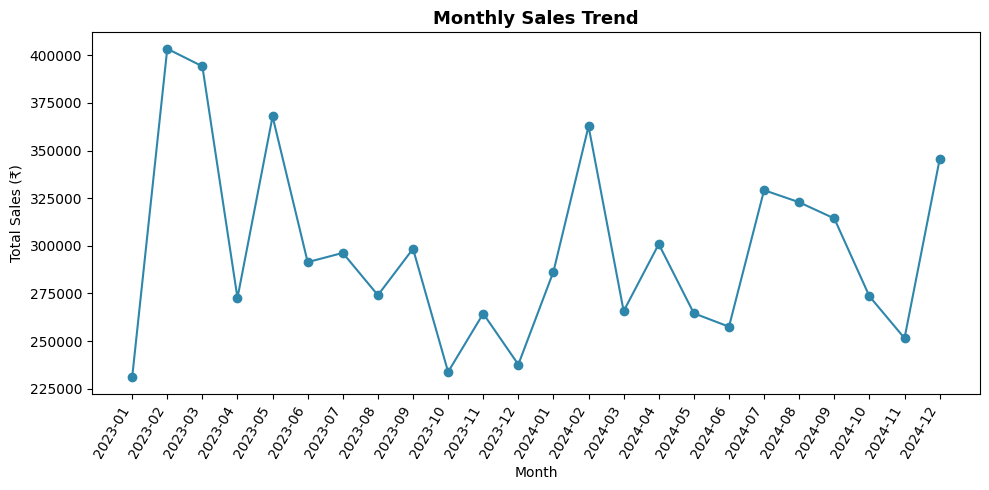

In [14]:
fig1 = monthly_sales_trend(list(monthly_sales.keys()), list(monthly_sales.values()))
plt.show()
# Question answered: Is revenue trending up, down, or seasonal over time?

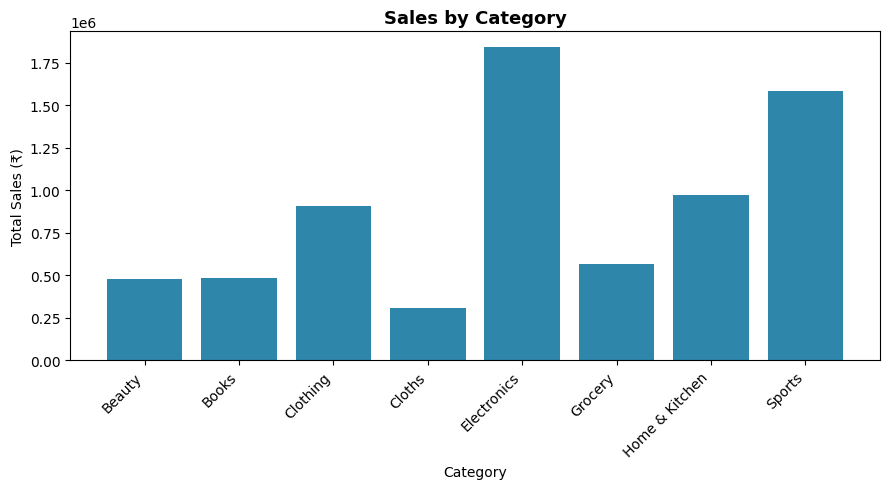

In [15]:
fig2 = sales_by_category(list(category_sales.keys()), list(category_sales.values()))
plt.show()
# Question answered: Which category brings in the most revenue?

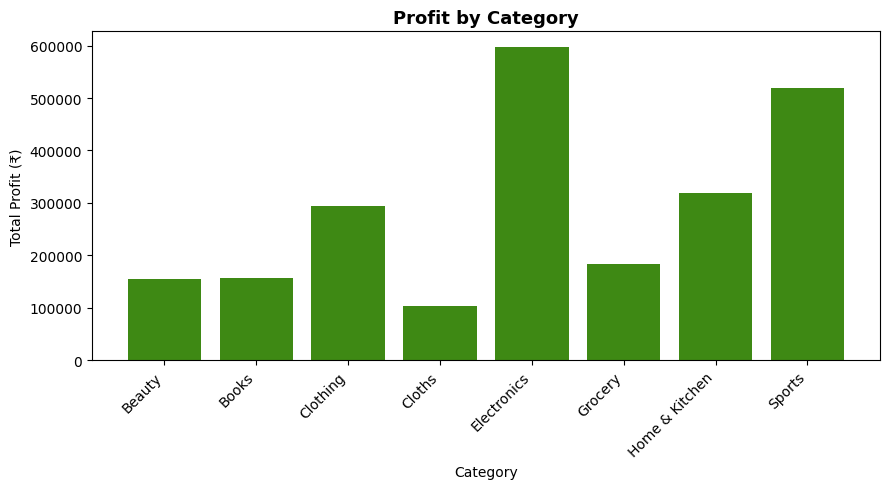

In [16]:
fig3 = profit_by_category(list(category_profit.keys()), list(category_profit.values()))
plt.show()
# Question answered: Which category is most PROFITABLE (not just highest revenue)?

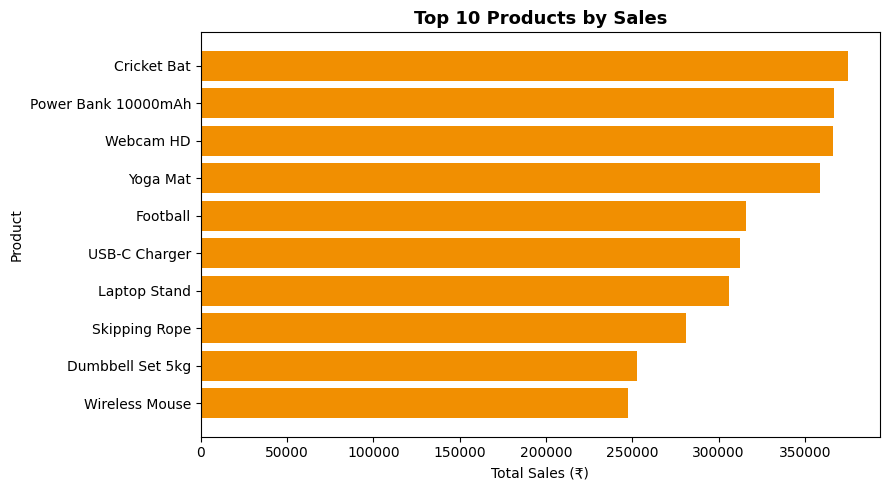

In [17]:
top10 = top_n(product_sales, n=10)
fig4 = top_products([p[0] for p in top10], [p[1] for p in top10])
plt.show()
# Question answered: Which individual products should we prioritize for inventory?

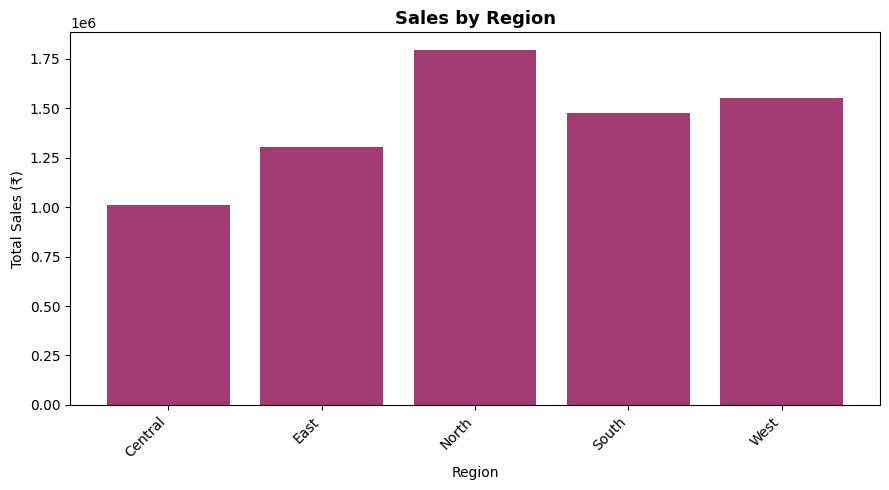

In [18]:
fig5 = sales_by_region(list(region_sales.keys()), list(region_sales.values()))
plt.show()
# Question answered: Which regions generate the most sales, and which need attention?

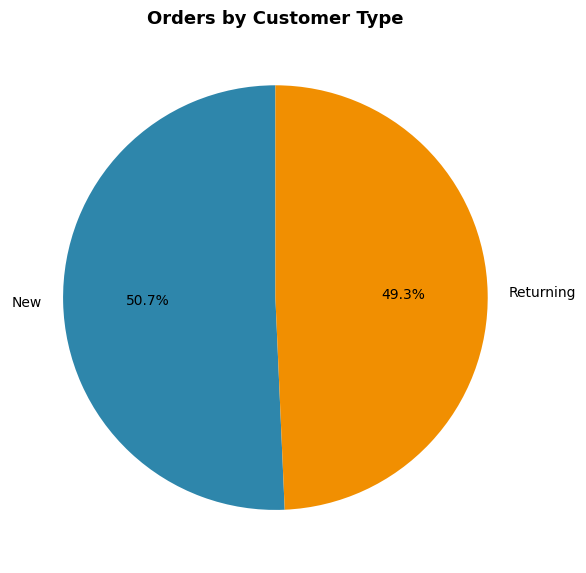

In [19]:
ctype_counts = clean_df["Customer_Type"].value_counts()
fig6 = orders_per_customer_type(ctype_counts.index.tolist(), ctype_counts.values.tolist())
plt.show()
# Question answered: What share of orders come from new vs. returning customers?

## 16. Business Insights

**Observation vs. Insight vs. Recommendation - an important distinction:**

- **Observation**: a plain fact from the data. *"Electronics had ₹1.8M in sales."*
- **Business Insight**: an observation combined with WHY it matters.
  *"Electronics leads all categories in revenue, suggesting strong and
  consistent customer demand for this category."*
- **Business Recommendation**: a specific action based on the insight.
  *"Prioritize Electronics inventory and marketing spend."*

Below, insights are generated directly from the numbers calculated
above - not invented.


In [20]:
top_cat = top_n(category_sales, n=1)[0]
weak_region = top_n(region_profit, n=1, ascending=True)[0]
top_city = top_n(city_sales, n=1)[0]
top_cust = top_customers_rev[0]

insights = [
    f"'{top_cat[0]}' generated the highest revenue (₹{top_cat[1]:,.0f}) of any category, "
    f"indicating strongest customer demand there.",

    f"'{weak_region[0]}' region shows the weakest profit (₹{weak_region[1]:,.0f}), "
    f"suggesting pricing, cost, or discount levels there should be reviewed.",

    f"'{top_city[0]}' is the top-performing city by sales (₹{top_city[1]:,.0f}), "
    f"making it a candidate for expanded marketing or stock allocation.",

    f"Customer {top_cust[0]} is the highest-value customer by revenue (₹{top_cust[1]:,.0f}), "
    f"worth considering for a loyalty or retention program.",

    f"{repeat_pct:.0f}% of customers placed more than one order, showing meaningful repeat "
    f"purchase behavior worth nurturing further.",

    f"Overall profit margin is {margin:.1f}%, giving a baseline to evaluate whether "
    f"future discounting strategies are sustainable.",

    f"Best sales month was {best_sales_month}, while best profit month was {best_profit_month}"
    + (" (the same month)" if best_sales_month == best_profit_month else " (a DIFFERENT month) - "
       "worth investigating why high sales didn't translate to the highest profit that month."),
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}\n")

1. 'Electronics' generated the highest revenue (₹1,842,756) of any category, indicating strongest customer demand there.

2. 'Central' region shows the weakest profit (₹327,455), suggesting pricing, cost, or discount levels there should be reviewed.

3. 'Ahmedabad' is the top-performing city by sales (₹554,570), making it a candidate for expanded marketing or stock allocation.

4. Customer CUST0482 is the highest-value customer by revenue (₹54,207), worth considering for a loyalty or retention program.

5. 89% of customers placed more than one order, showing meaningful repeat purchase behavior worth nurturing further.

6. Overall profit margin is 32.6%, giving a baseline to evaluate whether future discounting strategies are sustainable.

7. Best sales month was 2023-02, while best profit month was 2023-02 (the same month)



**Business Recommendations** (based only on the findings above):

1. Prioritize inventory and marketing budget toward the top-performing category and city.
2. Investigate the weakest-profit region for pricing, cost, or discount issues before cutting investment there.
3. Build a retention or loyalty offer targeted at top customers by revenue.
4. Review high-discount, low-profit-margin products identified in Section 10.
5. Study the gap (if any) between the best sales month and best profit month to understand discount timing effects.
6. Track the repeat-customer rate over time as a health metric for customer loyalty.


## 17. Final Conclusion

This notebook took a raw, messy retail sales CSV through a complete
Data Analyst workflow: understanding the business problem, cleaning the
data, converting it into NumPy arrays, calculating KPIs, filtering with
Boolean masks, grouping data the way SQL does, visualizing results, and
turning numbers into business insights and recommendations.

**What to do next:**
- Open `app.py` to see this same analysis as an interactive Streamlit dashboard.
- See `docs/STUDENT_CHALLENGE.md` for independent practice questions.
- See `README.md` for the full project write-up, GitHub setup, and deployment guide.
